In [2]:
import numpy as np
import matplotlib.pyplot as plt

CM = np.array([85.22,85.22,90.38,94.85,97.94,98.97])
EM = np.array([55.68,74.62,77.65,75.76,89.02,90.53])
QM = np.array([85.12,87.50,95.24,98.21,98.51,98.81])

topics = [CM, EM, QM]
totals = [97,88,112]

Diff1 = CM-EM
Diff2 = QM-EM

AvgDiffs = (Diff1+Diff2)/2
AvgDiff = np.mean(AvgDiffs)

print(Diff1)
print(Diff2)

print(AvgDiffs)
print(AvgDiff)

[29.54 10.6  12.73 19.09  8.92  8.44]
[29.44 12.88 17.59 22.45  9.49  8.28]
[29.49  11.74  15.16  20.77   9.205  8.36 ]
15.787499999999996


In [9]:
print(EM[5]-EM[1])
print(CM[3]-CM[2])
print(CM[5]-CM[4])
print(EM[3]-EM[1])

15.909999999999997
4.469999999999999
1.0300000000000011
1.1400000000000006


97
112
88


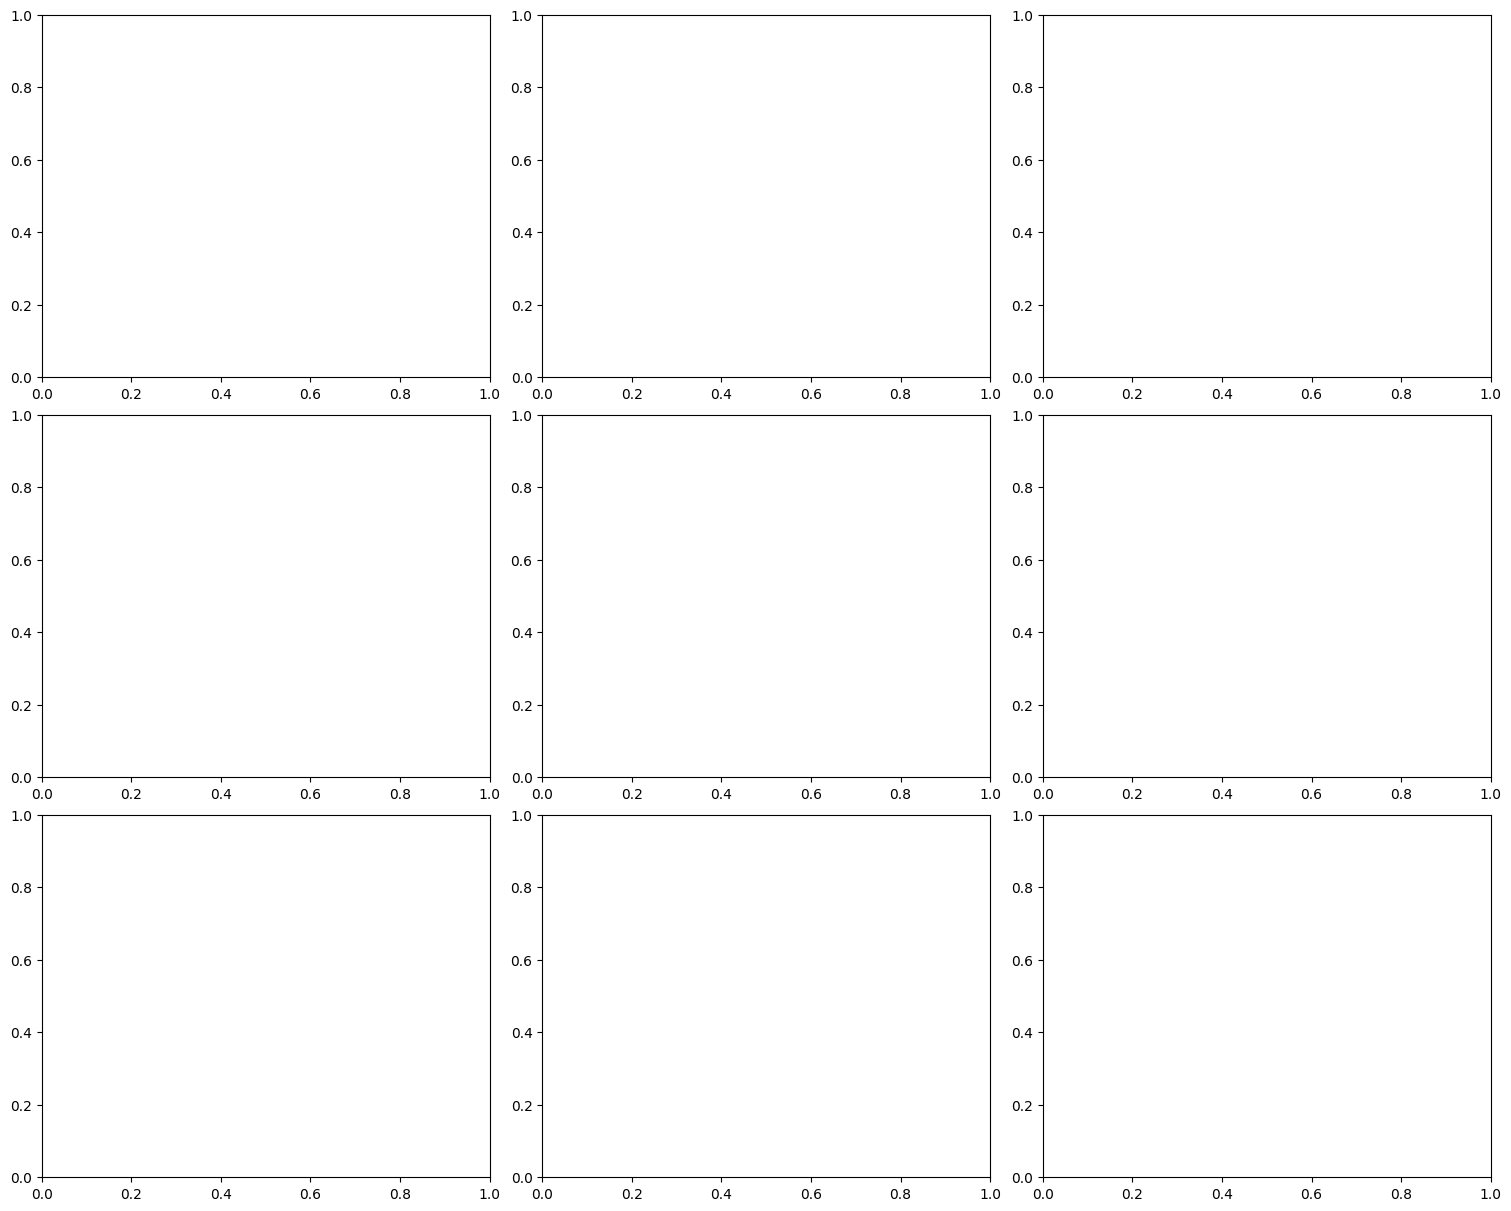

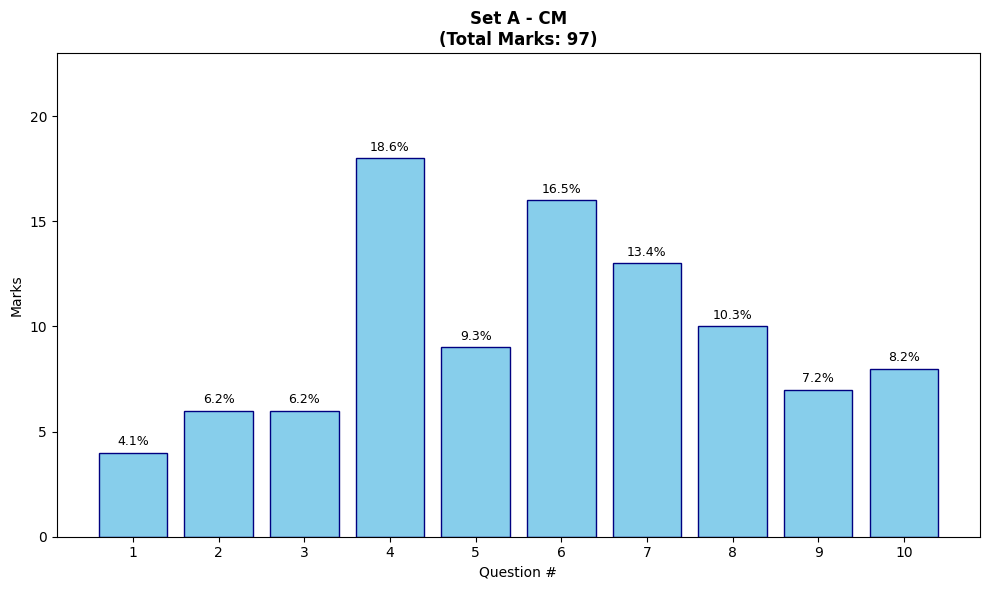

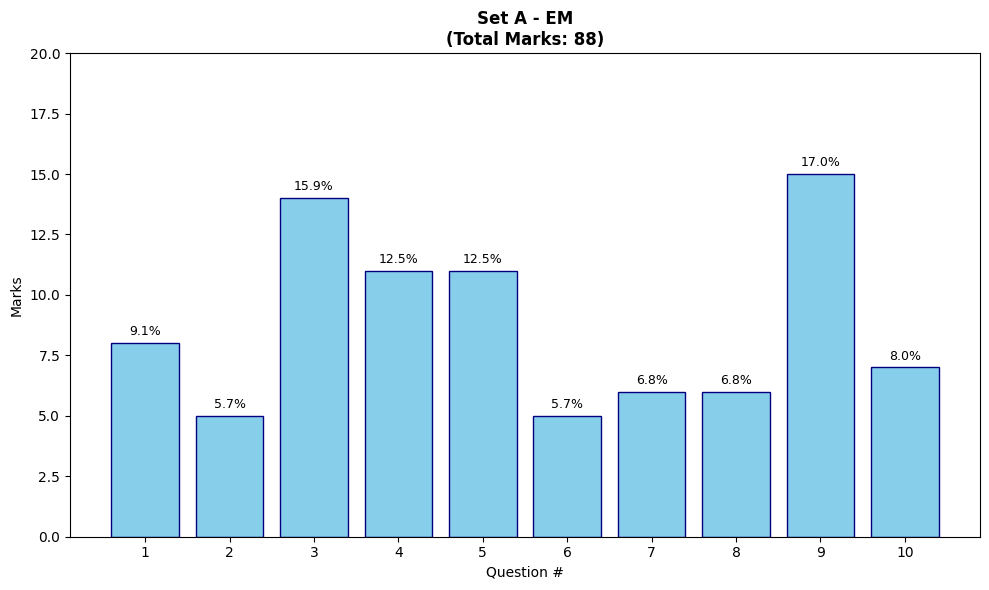

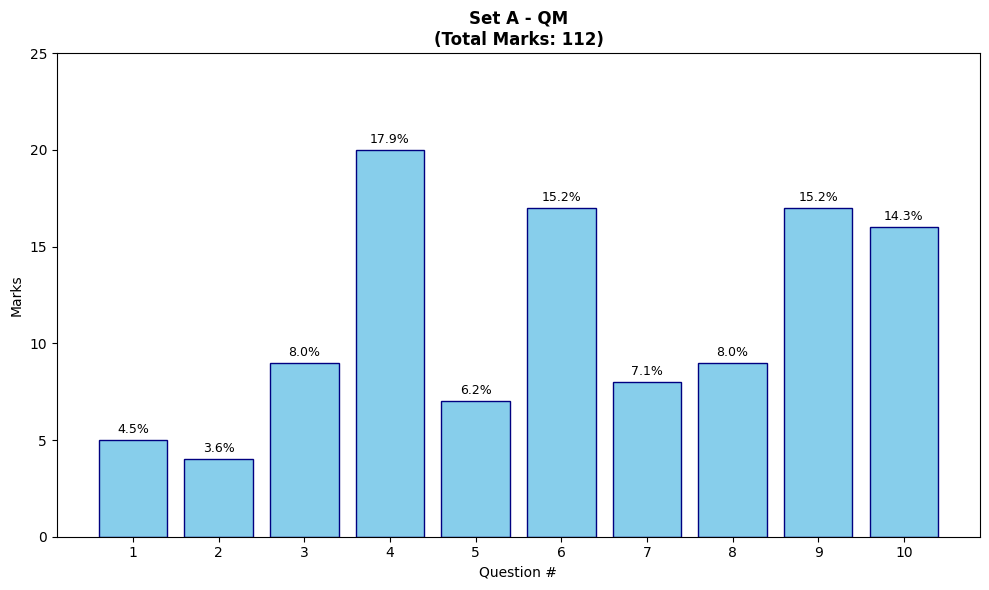

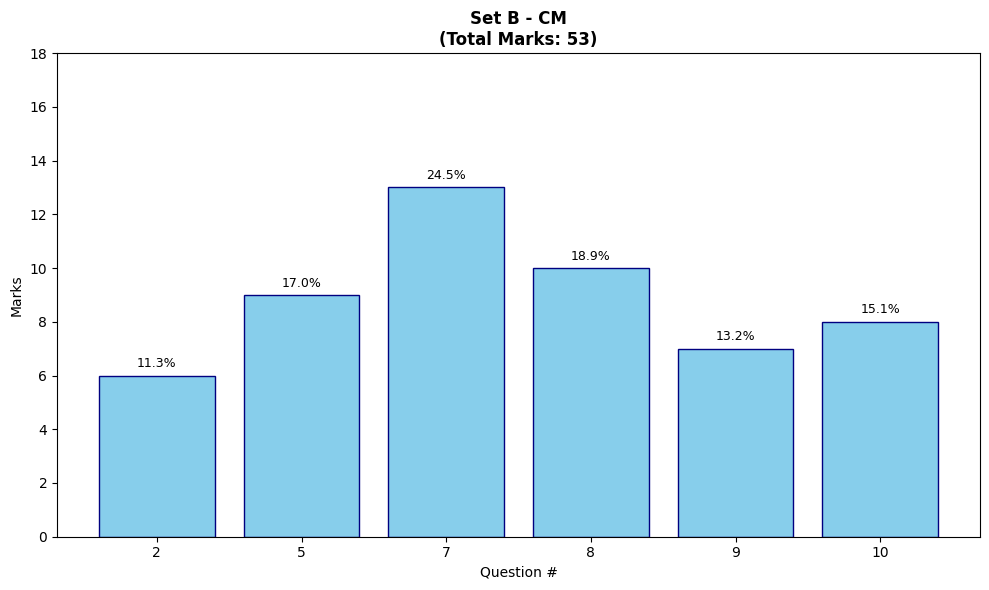

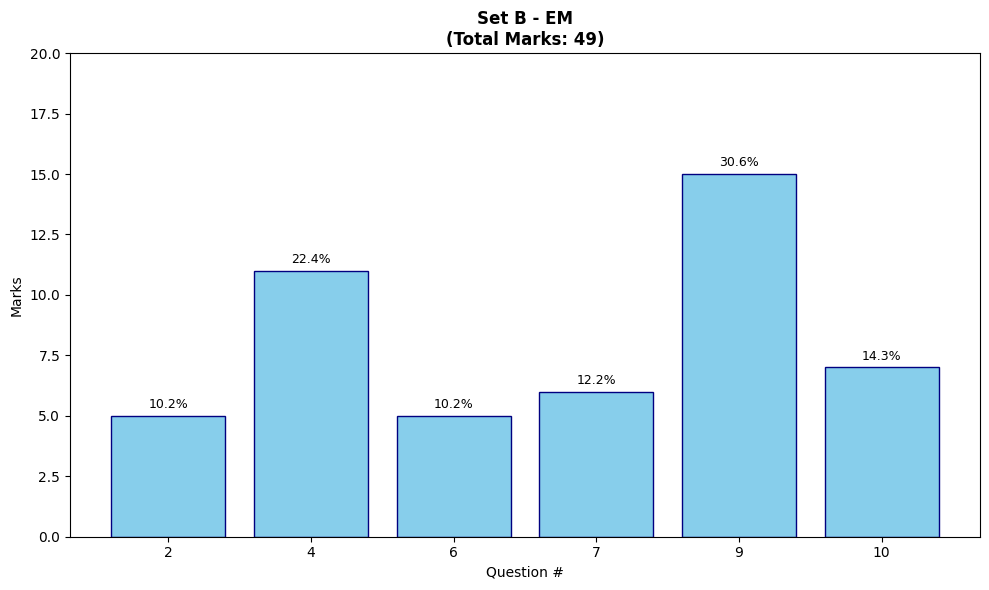

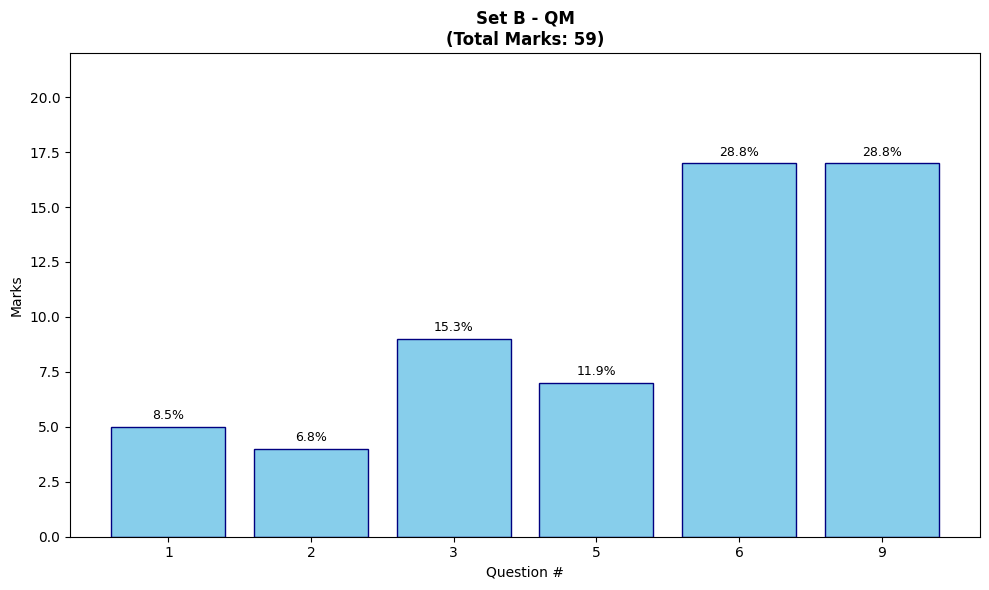

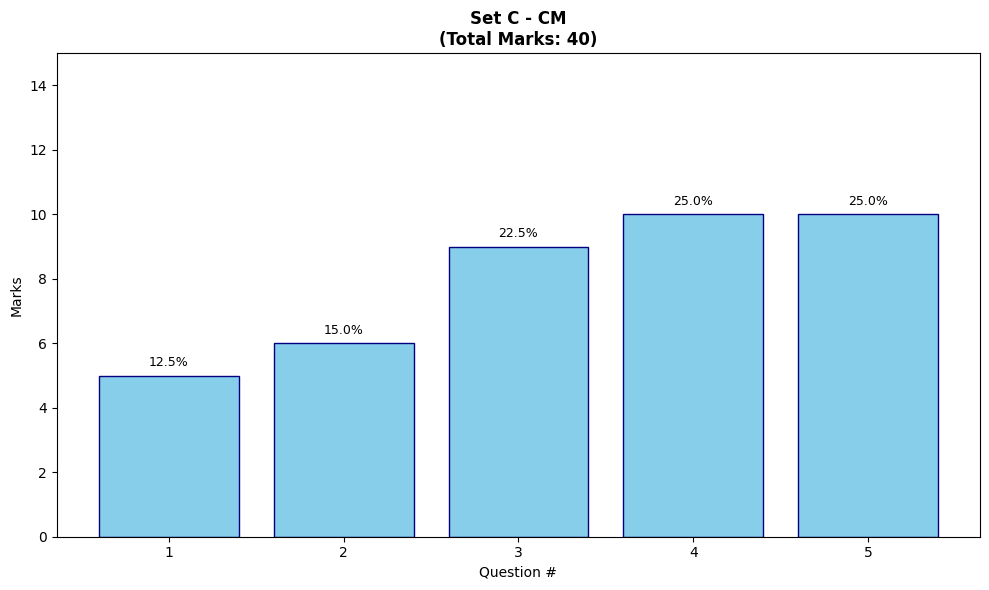

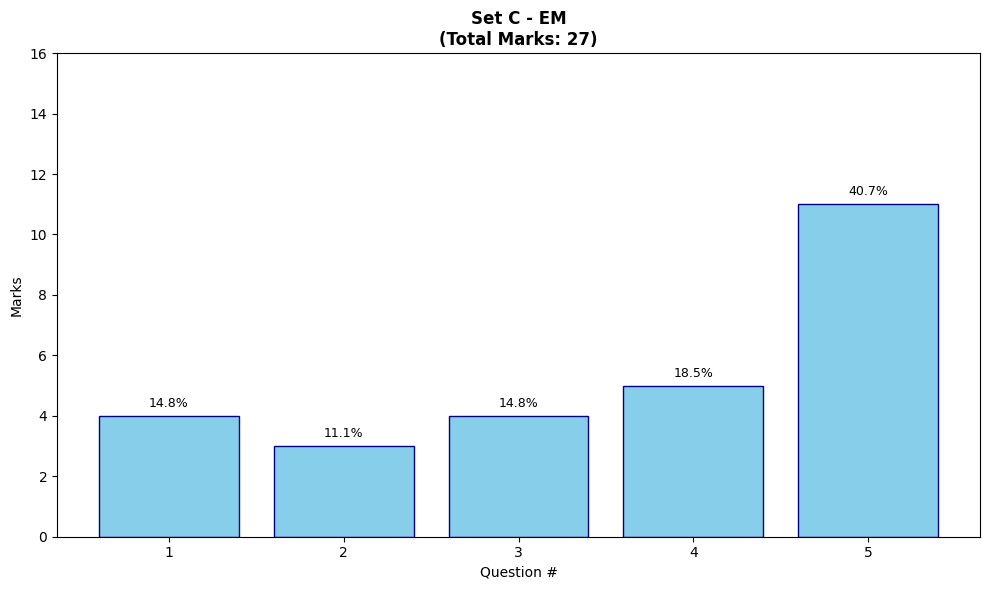

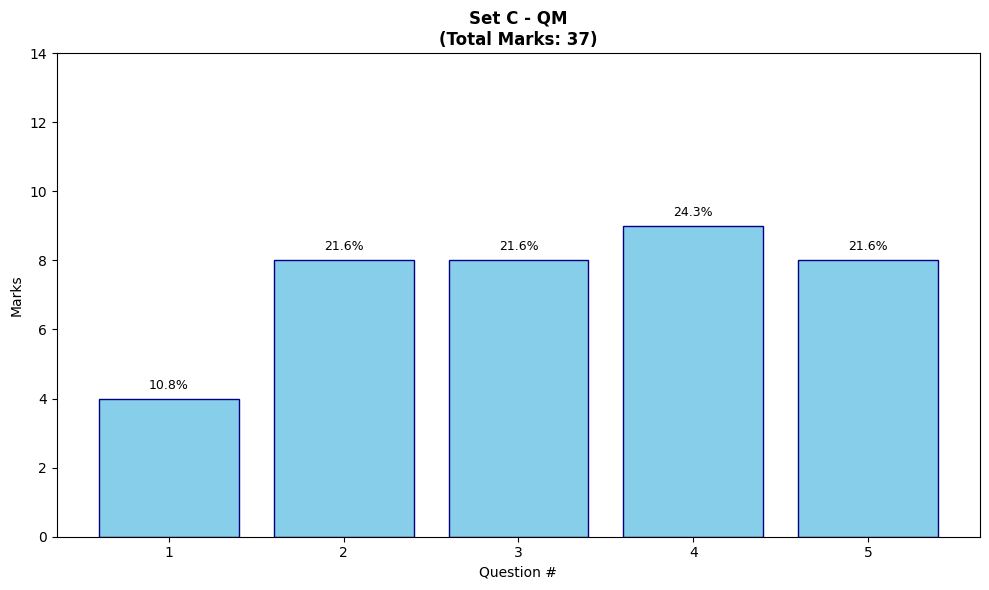

In [3]:
# Set A marks per question
CM_A_Marks = np.array([4,6,6,18,9,16,13,10,7,8])
QM_A_Marks = np.array([5,4,9,20,7,17,8,9,17,16])
EM_A_Marks = np.array([8,5,14,11,11,5,6,6,15,7])

print(np.sum(CM_A_Marks))
print(np.sum(QM_A_Marks))
print(np.sum(EM_A_Marks))

# Set B marks per question
CM_B_Marks = np.array([6,9,13,10,7,8]) # Q(2,5,7,8,9,10)
QM_B_Marks = np.array([5,4,9,7,17,17]) # Q(1,2,3,5,6,9)
EM_B_Marks = np.array([5,11,5,6,15,7]) # Q(2,4,6,7,9,10)

# Set C marks per question
CM_C_Marks = np.array([5,6,9,10,10])
QM_C_Marks = np.array([4,8,8,9,8])
EM_C_Marks = np.array([4,3,4,5,11])

data = {
    "CM": {"Set A": CM_A_Marks, "Set B": CM_B_Marks, "Set C": CM_C_Marks},
    "QM": {"Set A": QM_A_Marks, "Set B": QM_B_Marks, "Set C": QM_C_Marks},
    "EM": {"Set A": EM_A_Marks, "Set B": EM_B_Marks, "Set C": EM_C_Marks}
}

subjects = ["CM", "EM", "QM"]
sets = ["Set A", "Set B", "Set C"]


# Mapping for specific question numbers in Set B
# Note for PB1 1 and PB2 Set B swapped out Q10 in CM for Q2 and Q5 in EM for Q6
q_labels_map = {
    "Set B": {
        "CM": [2, 5, 7, 8, 9, 10],
        "QM": [1, 2, 3, 5, 6, 9],   
        "EM": [2, 4, 6, 7, 9, 10]
    }
}



fig, axes = plt.subplots(3, 3, figsize=(15, 12), constrained_layout=True)

# Assuming 'sets' and 'subjects' are your lists
for sname in sets:
    for subj in subjects:
        # 1. Create a brand new figure for every iteration
        plt.figure(figsize=(10, 6))
        
        marks = data[subj][sname]
        total = marks.sum()

        if sname in q_labels_map and subj in q_labels_map[sname]:
            questions = q_labels_map[sname][subj]
        else:
            questions = np.arange(1, len(marks) + 1)

        x_pos = np.arange(len(marks))
        
        # 2. Use plt.bar instead of ax.bar
        bars = plt.bar(x_pos, marks, color='skyblue', edgecolor='navy')

        for bar in bars:
            height = bar.get_height()
            weight = (height / total) * 100
            plt.text(bar.get_x() + bar.get_width()/2., height + 0.2,
                    f'{weight:.1f}%', ha='center', va='bottom', fontsize=9)

        # 3. Use pyplot (plt) functions to set labels/titles
        plt.xticks(x_pos, questions)
        plt.title(f"{sname} - {subj}\n(Total Marks: {total})", fontweight='bold')
        plt.xlabel("Question #")
        plt.ylabel("Marks")
        plt.ylim(0, max(marks) + 5)
        
        # 4. Show (or save) the individual figure before starting the next loop
        plt.tight_layout()
        plt.show()